<a href="https://colab.research.google.com/github/hj245668/ds6_mainquest/blob/main/mq_1124_hyunjin0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

10-6. 프로젝트 : Finance Time Series 데이터 활용하기
프로젝트 요약
1. 프로젝트 : Data Labeling
2. 프로젝트 : Feature Engineering
3. 프로젝트 : Model Training

이번 노드에서 프로젝트는 총 3가지로 구성되어있습니다. Data Labeling 방법과 Feature Engineering 방법에 대해 생각해보며 model training을 통해 성능을 개선시켜봅시다.

프로젝트 1, 2를 정상적인 흐름대로 진행하기
프로젝트 3에서 다양한 방법을 사용하여 기존의 결과와 비교 분석 시도하기
다양한 방법을 사용하여 성능향상을 시도하기
앞에서 했던 내용을 기억하면서 코드를 작성해봅시다.

1. 프로젝트 : Data Labeling
위에서 배운 Data Labeling 4가지를 직접 적용해봅시다.

① Price Change Direction 적용하기
② Using Moving Average 적용하기
③ Local Min-Max 적용하기
④ Trend Scanning 적용하기

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<Axes: xlabel='time'>

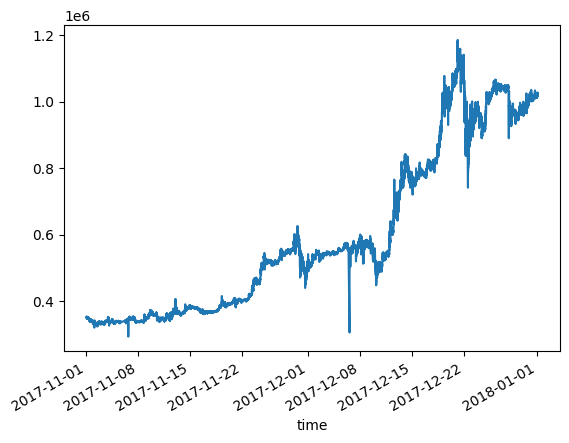

In [5]:
# 데이터 경로
DATA_PATH = '/content/drive/MyDrive/SQL_modu/1124_finance/'

# 데이터 불러오기
modify_data = pd.read_csv(os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick.csv'), index_col=0, parse_dates=True)

# 불러온 데이터 시각화하기
modify_data.loc['2017-11-01':'2017-12-31','close'].plot()

① Price Change Direction

In [7]:
# Q. 코드를 작성해주세요

# window 지정
window = 10 # 앞서 사용한 window의 값은 10입니다.

# momentum_signal 만들기
momentum_signal = np.sign(np.sign(modify_data['close'] - modify_data['close'].shift(window)) + 1) # modify_data['close'].shift(window)활용

# s_momentum_signal 만들기
s_momentum_signal = pd.Series(momentum_signal, index=modify_data.index) #[[YOUR CODE]] # 데이터 활용을 위해 pd.Series를 사용합니다.

,close
time,
2017-09-25 03:00:00,NaN
2017-09-25 03:01:00,NaN
2017-09-25 03:02:00,NaN
2017-09-25 03:05:00,NaN
2017-09-25 03:06:00,NaN
2017-09-25 03:07:00,NaN
2017-09-25 03:10:00,NaN
2017-09-25 03:11:00,NaN
2017-09-25 03:12:00,NaN


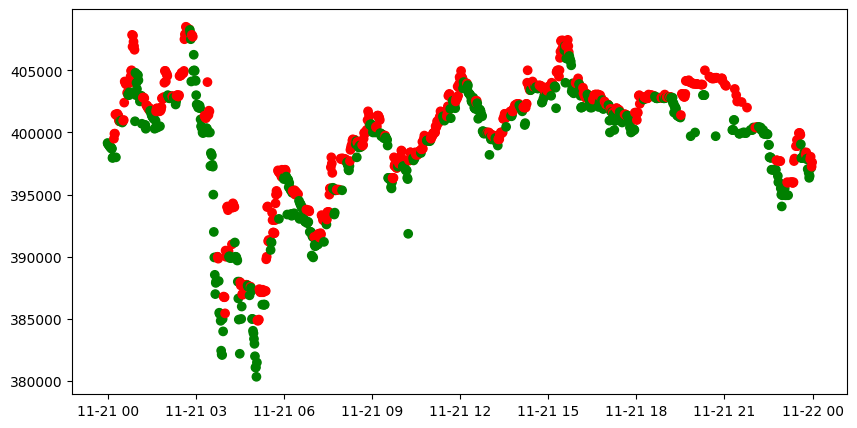

In [11]:
# Q. 코드를 작성해주세요

# 기존 데이터 만들기
sub_data = modify_data.loc['2017-11-21', 'close']
# loc를 활용하여 2017-11-21부터 close(종가)까지 가져오기

# 수식 적용된 데이터 만들기
c_sig = s_momentum_signal.loc['2017-11-21'] # loc를 활용하여 2017-11-21의 시간대별 값을 가져오기

# 두 데이터의 비교를 위한 색상 바꾸기
c_sig['color'] = np.where(c_sig == 1, 'red', 'green')
# np.where 사용

# 시각화하기
plt.figure(figsize=(10,5))
plt.scatter(sub_data.index, sub_data, c=c_sig['color'])

s_momentum_signal.head(15)

② Using Moving Average

In [12]:
# Q. 코드를 작성해주세요

# momentum_signal
momentum_signal = np.sign(np.sign(modify_data['close'] - modify_data['close'].rolling(window).mean()) + 1)
# modify_data['close'].rolling(window).mean() 활용

# s_momentum_signal
s_momentum_signal = pd.Series(momentum_signal, index=modify_data.index)

,close
time,
2017-09-25 03:00:00,NaN
2017-09-25 03:01:00,NaN
2017-09-25 03:02:00,NaN
2017-09-25 03:05:00,NaN
2017-09-25 03:06:00,NaN
2017-09-25 03:07:00,NaN
2017-09-25 03:10:00,NaN
2017-09-25 03:11:00,NaN
2017-09-25 03:12:00,NaN


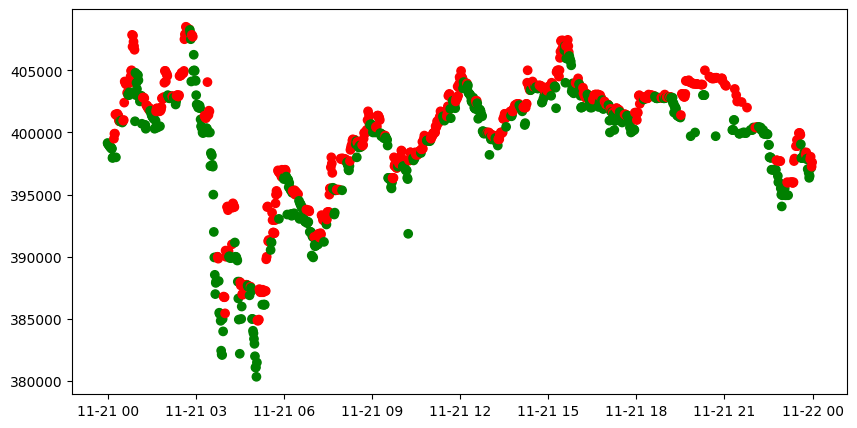

In [14]:
# Q. 코드를 작성해주세요

# 기존 데이터 만들기
sub_data = modify_data.loc['2017-11-21', 'close']

# 수식 적용된 데이터 만들기
c_sig = s_momentum_signal.loc['2017-11-21']

# 두 데이터의 비교를 위한 색상 바꾸기
c_sig['color'] = np.where(c_sig == 1, 'red', 'green')

# 시각화하기
plt.figure(figsize=(10,5))
plt.scatter(sub_data.index, sub_data, c=c_sig['color'])

s_momentum_signal.head(15)

③ Local Min-Max 적용

In [15]:
# Local min / max 를 추출하기 위한 함수
def get_local_min_max(close, wait=3):
    min_value = close.iloc[0]
    max_value = close.iloc[0] # ①
    n_cnt_min, n_cnt_max = 0, 0

    mins, maxes = [], []
    min_idxes, max_idxes = [], []
    b_min_update, b_max_update = False, False

    for idx, val in zip(close.index[1:], close.values[1:]):
        if val < min_value:
            min_value = val
            mins.append(min_value)
            min_idxes.append(idx)
            n_cnt_min = 0
            b_min_update = True
        if val > max_value:
            max_value = val # ②
            maxes.append(max_value) # ③
            max_idxes.append(idx)
            n_cnt_max = 0
            b_max_update = True # ④

        if not b_max_update:
            b_min_update = False
            n_cnt_min += 1
            if n_cnt_min >= wait:
                max_value = min_value
                n_cnt_min = 0

        if not b_min_update:
            b_max_update = False  # ⑤
            n_cnt_max += 1  # ⑥
            if n_cnt_max >= wait:
                min_value = max_value # ⑦
                n_cnt_max = 0

    return pd.DataFrame.from_dict({'min_time': min_idxes, 'local_min': mins}), pd.DataFrame.from_dict({'max_time': max_idxes, 'local_max': maxes}) # ⑧

In [16]:
# Local mins, maxes를 확인
mins, maxes = get_local_min_max(sub_data, wait=3)

# mins, maxes 확인
print(mins)
print('--'*20)
print(maxes)

               min_time  local_min
0   2017-11-21 00:01:00     399050
1   2017-11-21 00:03:00     399000
2   2017-11-21 00:04:00     398900
3   2017-11-21 00:05:00     398850
4   2017-11-21 00:06:00     398800
..                  ...        ...
472 2017-11-21 23:48:00     397850
473 2017-11-21 23:50:00     397050
474 2017-11-21 23:52:00     396750
475 2017-11-21 23:53:00     396350
476 2017-11-21 23:59:00     397600

[477 rows x 2 columns]
----------------------------------------
               max_time  local_max
0   2017-11-21 00:13:00     399500
1   2017-11-21 00:14:00     399900
2   2017-11-21 00:16:00     401450
3   2017-11-21 00:19:00     401350
4   2017-11-21 00:20:00     401500
..                  ...        ...
268 2017-11-21 23:41:00     398050
269 2017-11-21 23:43:00     398400
270 2017-11-21 23:46:00     398200
271 2017-11-21 23:47:00     398400
272 2017-11-21 23:56:00     398050

[273 rows x 2 columns]


(376546.5, 412585.0)

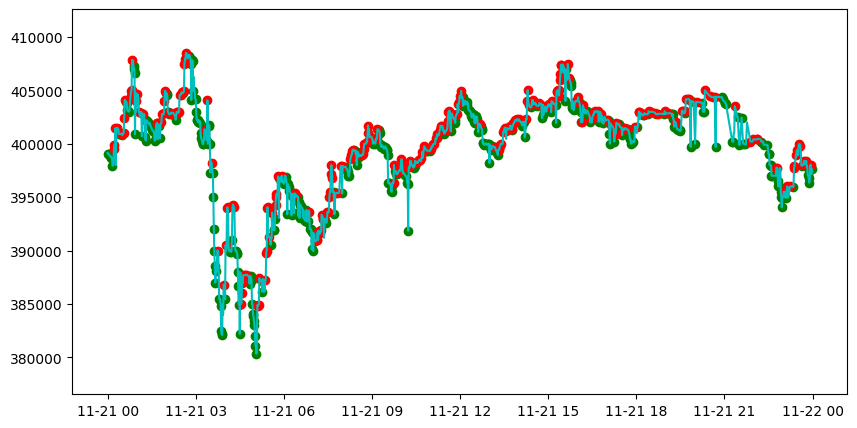

In [17]:
# Q. 코드를 작성해주세요

# subplots 및 plot 생성
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(sub_data, 'c')

# min_time, local_min을 활용한 scatter plot 생성
ax.scatter(mins.min_time, mins.local_min, c='green')

# maxes_time, local_max를 활용한 scatter plot 생성
ax.scatter(maxes.max_time, maxes.local_max, c='red')

# y축 설정
ax.set_ylim([sub_data.min() * 0.99, sub_data.max()  * 1.01])

④ Trend Scanning

In [18]:
def t_val_lin_r(close):
    import statsmodels.api as sml

    # t-value from a linear trend
    x = np.ones((close.shape[0], 2))
    x[:, 1] = np.arange(close.shape[0])
    ols = sml.OLS(close, x).fit()
    return ols.tvalues[1]

In [19]:
look_forward_window = 60
min_sample_length = 5
step = 1
t1_array = []
t_values_array = []

In [20]:
# 이 코드 블럭은 실행에 20~30분정도 걸립니다.

molecule = modify_data['2017-11-01':'2017-11-30'].index
label = pd.DataFrame(index=molecule, columns=['t1', 't_val', 'bin'])
tmp_out = []

for ind in tqdm(molecule):
    subset = modify_data.loc[ind:, 'close'].iloc[:look_forward_window]  # 전방 탐색을 위한 샘플 추출
    if look_forward_window > subset.shape[0]:
        continue

    tmp_subset = pd.Series(index=subset.index[min_sample_length-1:subset.shape[0]-1])
    tval = []

    # 회귀분석을 통해 t 통계량값을 이용하여 추세 추정
    for forward_window in np.arange(min_sample_length, subset.shape[0]):
        df = subset.iloc[:forward_window]
        tval.append(t_val_lin_r(df.values))

    tmp_subset.loc[tmp_subset.index] = np.array(tval)
    idx_max = tmp_subset.replace([-np.inf, np.inf, np.nan], 0).abs().idxmax()
    tmp_t_val = tmp_subset[idx_max]
    tmp_out.append([tmp_subset.index[-1], tmp_t_val, np.sign(tmp_t_val)])

label.loc[molecule] = np.array(tmp_out)  # prevent leakage

label['t1'] = pd.to_datetime(label['t1'])
label['bin'] = pd.to_numeric(label['bin'], downcast='signed')

100%|██████████| 33384/33384 [15:15<00:00, 36.48it/s]


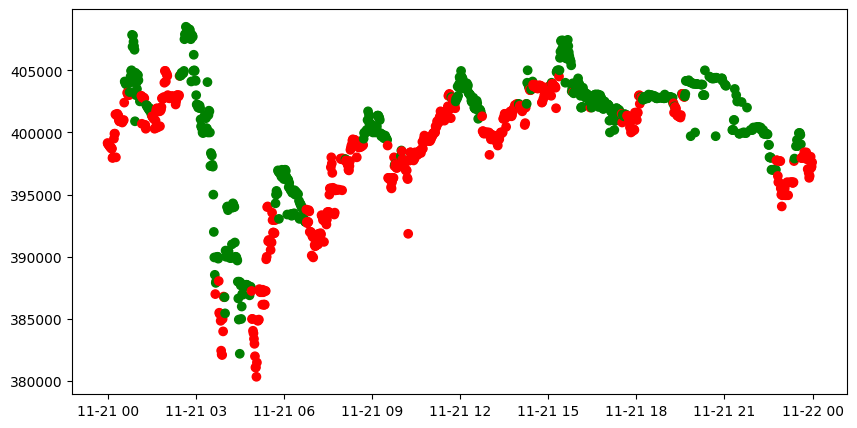

In [21]:
# 시각화
sub_data = modify_data.loc['2017-11-21', 'close']
c_sig = label['bin'].loc['2017-11-21']
c_sig['color'] = np.where(c_sig == 1, 'red', 'green')

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(sub_data.index, sub_data.values, c=c_sig['color'])

2. 프로젝트 : Feature Engineering

In [26]:
!pip install ta==0.9.0
!pip install shap

In [44]:
import datetime
import sys
import os
import re
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

# 이거 두개는 LMS에서는 내부 파일이 존재함
# sys.path.append('/aiffel/aiffel/fnguide/data/')
# from libs.feature_importance import importance as imp

from sklearn.feature_selection import SequentialFeatureSelector, RFECV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [69]:
"""
mlfinlab
"""

"""
Module which implements feature importance algorithms as described in Chapter 8 of Advances in Financial Machine
Learning and Clustered Feature Importance algorithms as described in Chapter 6 Section 6.5.2 of Machine Learning for
Asset Managers.
"""

import pandas as pd
import numpy as np
from sklearn.metrics import log_loss


def mean_decrease_impurity(model, feature_names, clustered_subsets=None):
    """
    Advances in Financial Machine Learning, Snippet 8.2, page 115.
    MDI Feature importance
    Mean decrease impurity (MDI) is a fast, explanatory-importance (in-sample, IS) method specific to tree-based
    classifiers, like RF. At each node of each decision tree, the selected feature splits the subset it received in
    such a way that impurity is decreased. Therefore, we can derive for each decision tree how much of the overall
    impurity decrease can be assigned to each feature. And given that we have a forest of trees, we can average those
    values across all estimators and rank the features accordingly.
    Tip:
    Masking effects take place when some features are systematically ignored by tree-based classifiers in favor of
    others. In order to avoid them, set max_features=int(1) when using sklearn’s RF class. In this way, only one random
    feature is considered per level.
    Notes:
    * MDI cannot be generalized to other non-tree based classifiers
    * The procedure is obviously in-sample.
    * Every feature will have some importance, even if they have no predictive power whatsoever.
    * MDI has the nice property that feature importances add up to 1, and every feature importance is bounded between 0 and 1.
    * method does not address substitution effects in the presence of correlated features. MDI dilutes the importance of
      substitute features, because of their interchangeability: The importance of two identical features will be halved,
      as they are randomly chosen with equal probability.
    * Sklearn’s RandomForest class implements MDI as the default feature importance score. This choice is likely
      motivated by the ability to compute MDI on the fly, with minimum computational cost.
    Clustered Feature Importance( Machine Learning for Asset Manager snippet 6.4 page 86) :
    Clustered MDI  is the  modified version of MDI (Mean Decreased Impurity). It  is robust to substitution effect that
    takes place when two or more explanatory variables share a substantial amount of information (predictive power).CFI
    algorithm described by Dr Marcos Lopez de Prado  in Clustered Feature  Importance section of book Machine Learning
    for Asset Manager. Here  instead of  taking the importance  of  every feature, we consider the importance of every
    feature subsets, thus every feature receive the importance of subset it belongs to.
    :param model: (model object): Trained tree based classifier.
    :param feature_names: (list): Array of feature names.
    :param clustered_subsets: (list) Feature clusters for Clustered Feature Importance (CFI). Default None will not apply CFI.
                              Structure of the input must be a list of list/s i.e. a list containing the clusters/subsets of feature
                              name/s inside a list. E.g- [['I_0','I_1','R_0','R_1'],['N_1','N_2'],['R_3']]
    :return: (pd.DataFrame): Mean and standard deviation feature importance.
    """
    # Feature importance based on in-sample (IS) mean impurity reduction
    feature_imp_df = {i: tree.feature_importances_ for i, tree in enumerate(model.estimators_)}
    feature_imp_df = pd.DataFrame.from_dict(feature_imp_df, orient='index')
    feature_imp_df.columns = feature_names

    # Make sure that features with zero importance are not averaged, since the only reason for a 0 is that the feature
    # was not randomly chosen. Replace those values with np.nan
    feature_imp_df = feature_imp_df.replace(0, np.nan)  # Because max_features = 1

    if clustered_subsets is not None:
        # Getting subset wise importance
        importance = pd.DataFrame(index=feature_names, columns=['mean', 'std'])
        for subset in clustered_subsets: # Iterating over each cluster
            subset_feat_imp = feature_imp_df[subset].sum(axis=1)
            # Importance of each feature within a subsets is equal to the importance of that subset
            importance.loc[subset, 'mean'] = subset_feat_imp.mean()
            importance.loc[subset, 'std'] = subset_feat_imp.std()*subset_feat_imp.shape[0]**-.5
    else:
        importance = pd.concat({'mean': feature_imp_df.mean(),
                                'std': feature_imp_df.std() * feature_imp_df.shape[0] ** -0.5},
                               axis=1)

    importance /= importance['mean'].sum()
    return importance


def mean_decrease_accuracy(model, X, y, cv_gen, clustered_subsets=None, sample_weight_train=None,
                           sample_weight_score=None, scoring=log_loss, random_state=42):
    """
    Advances in Financial Machine Learning, Snippet 8.3, page 116-117.
    MDA Feature Importance
    Mean decrease accuracy (MDA) is a slow, predictive-importance (out-of-sample, OOS) method. First, it fits a
    classifier; second, it derives its performance OOS according to some performance score (accuracy, negative log-loss,
    etc.); third, it permutates each column of the features matrix (X), one column at a time, deriving the performance
    OOS after each column’s permutation. The importance of a feature is a function of the loss in performance caused by
    its column’s permutation. Some relevant considerations include:
    * This method can be applied to any classifier, not only tree-based classifiers.
    * MDA is not limited to accuracy as the sole performance score. For example, in the context of meta-labeling
      applications, we may prefer to score a classifier with F1 rather than accuracy. That is one reason a better
      descriptive name would have been “permutation importance.” When the scoring function does not correspond to a
      metric space, MDA results should be used as a ranking.
    * Like MDI, the procedure is also susceptible to substitution effects in the presence of correlated features.
      Given two identical features, MDA always considers one to be redundant to the other. Unfortunately, MDA will make
      both features appear to be outright irrelevant, even if they are critical.
    * Unlike MDI, it is possible that MDA concludes that all features are unimportant. That is because MDA is based on
      OOS performance.
    * The CV must be purged and embargoed.
    Clustered Feature Importance( Machine Learning for Asset Manager snippet 6.5 page 87) :
    Clustered MDA is the modified version of MDA (Mean Decreased Accuracy). It is robust to substitution effect that takes
    place when two or more explanatory variables share a substantial amount of information (predictive power).CFI algorithm
    described by Dr Marcos Lopez de Prado  in Clustered Feature  Importance (Presentation Slides)
    https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3517595. Instead of shuffling (permutating) all variables
    individually (like in MDA), we shuffle all variables in cluster together. Next, we follow all the  rest of the
    steps as in MDA. It can used by simply specifying the clustered_subsets argument.
    :param model: (sklearn.Classifier): Any sklearn classifier.
    :param X: (pd.DataFrame): Train set features.
    :param y: (pd.DataFrame, np.array): Train set labels.
    :param cv_gen: (cross_validation.PurgedKFold): Cross-validation object.
    :param clustered_subsets: (list) Feature clusters for Clustered Feature Importance (CFI). Default None will not apply CFI.
                              Structure of the input must be a list of list/s i.e. a list containing the clusters/subsets of feature
                              name/s inside a list. E.g- [['I_0','I_1','R_0','R_1'],['N_1','N_2'],['R_3']]
    :param sample_weight_train: (np.array) Sample weights used to train the model for each record in the dataset.
    :param sample_weight_score: (np.array) Sample weights used to evaluate the model quality.
    :param scoring: (function): Scoring function used to determine importance.
    :param random_state: (int) Random seed for shuffling the features.
    :return: (pd.DataFrame): Mean and standard deviation of feature importance.
    """

    if sample_weight_train is None:
        sample_weight_train = np.ones((X.shape[0],))

    if sample_weight_score is None:
        sample_weight_score = np.ones((X.shape[0],))

    fold_metrics_values, features_metrics_values = pd.Series(dtype='float64'), pd.DataFrame(columns=X.columns)
    # Generating a numpy random state object for the given random_state
    rs_obj = np.random.RandomState(seed=random_state)
    # Clustered feature subsets will be used for CFI if clustered_subsets exists else will operate on the single column as MDA
    feature_sets = clustered_subsets if clustered_subsets else [[x] for x in X.columns]
    for i, (train, test) in enumerate(cv_gen.split(X=X)):
        fit = model.fit(X=X.iloc[train, :], y=y.iloc[train], sample_weight=sample_weight_train[train])
        pred = fit.predict(X.iloc[test, :])

        # Get overall metrics value on out-of-sample fold
        if scoring == log_loss:
            prob = fit.predict_proba(X.iloc[test, :])
            fold_metrics_values.loc[i] = -scoring(y.iloc[test], prob, sample_weight=sample_weight_score[test],
                                                  labels=model.classes_)
        else:
            fold_metrics_values.loc[i] = scoring(y.iloc[test], pred, sample_weight=sample_weight_score[test])

        # Get feature specific metric on out-of-sample fold
        for j in feature_sets:
            X1_ = X.iloc[test, :].copy(deep=True)
            for j_i in j:
                rs_obj.shuffle(X1_[j_i].values)  # Permutation of a single column for MDA or through the whole subset for CFI
            if scoring == log_loss:
                prob = fit.predict_proba(X1_)
                features_metrics_values.loc[i, j] = -scoring(y.iloc[test], prob,
                                                             sample_weight=sample_weight_score[test],
                                                             labels=model.classes_)
            else:
                pred = fit.predict(X1_)
                features_metrics_values.loc[i, j] = scoring(y.iloc[test], pred,
                                                            sample_weight=sample_weight_score[test])

    importance = (-features_metrics_values).add(fold_metrics_values, axis=0)
    if scoring == log_loss:
        importance = importance / -features_metrics_values
    else:
        importance = importance / (1.0 - features_metrics_values).replace(0, np.nan)
    importance = pd.concat({'mean': importance.mean(), 'std': importance.std() * importance.shape[0] ** -.5}, axis=1)
    importance.replace([-np.inf, np.nan], 0, inplace=True)  # Replace infinite values

    return importance

In [70]:
# 데이터 경로 설정
DATA_PATH = '/content/drive/MyDrive/SQL_modu/1124_finance/'
anno_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick_label.pkl')
target_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick.csv')

# 데이터 불러오기
df_modify_data = pd.read_csv(target_file_name, index_col=0, parse_dates=True)
df_label_data = pd.read_pickle(anno_file_name)
df_sub_modify_data = df_modify_data.loc[df_label_data.index]

# 학습 시간 단축을 위해 여기선 편의상 1000개의 데이터만 가져옵니다.
df_sub_modify_data = df_sub_modify_data.iloc[:1000]

② Technical Index 적용

In [71]:
# 기술적 지표를 적용합니다.

mt = 1
fillna = False
df_ = df_sub_modify_data.copy()
open, high, low, close, volume = 'open', 'high', 'low', 'close', 'volume'
cols = [open, high, low, close, volume]

## Volume Index
# Chaikin Money Flow
df_["volume_cmf"] = ta.volume.ChaikinMoneyFlowIndicator(
                        high=df_[high], low=df_[low], close=df_[close], volume=df_[volume], window=20*mt, fillna=fillna
                    ).chaikin_money_flow()
# Force Index
df_["volume_fi"] = ta.volume.ForceIndexIndicator(
                        close=df_[close], volume=df_[volume], window=15*mt, fillna=fillna
                    ).force_index()
# Money Flow Indicator
df_["volume_mfi"] = ta.volume.MFIIndicator(
                        high=df_[high],
                        low=df_[low],
                        close=df_[close],
                        volume=df_[volume],
                        window=15*mt,
                        fillna=fillna,
                    ).money_flow_index()
# Ease of Movement
df_["volume_sma_em"] = ta.volume.EaseOfMovementIndicator(
                            high=df_[high], low=df_[low], volume=df_[volume], window=15*mt, fillna=fillna
                        ).sma_ease_of_movement()

# Volume Price Trend
df_["volume_vpt"] = ta.volume.VolumePriceTrendIndicator(
                        close=df_[close], volume=df_[volume], fillna=fillna
                    ).volume_price_trend()

## volatility index
# Average True Range
df_["volatility_atr"] = ta.volatility.AverageTrueRange(
                            close=df_[close], high=df_[high], low=df_[low], window=10*mt, fillna=fillna
                        ).average_true_range()

# Ulcer Index
df_["volatility_ui"] = ta.volatility.UlcerIndex(
                            close=df_[close], window=15*mt, fillna=fillna
                        ).ulcer_index()

## trend index
# MACD
df_["trend_macd_diff"] = ta.trend.MACD(
                            close=df_[close], window_slow=25*mt, window_fast=10*mt, window_sign=9, fillna=fillna
                        ).macd_diff()

# Average Directional Movement Index (ADX)
df_["trend_adx"] = ta.trend.ADXIndicator(
                        high=df_[high], low=df_[low], close=df_[close], window=15*mt, fillna=fillna
                    ).adx()

# TRIX Indicator
df_["trend_trix"] = ta.trend.TRIXIndicator(
                        close=df_[close], window=15*mt, fillna=fillna
                    ).trix()

# Mass Index
df_["trend_mass_index"] = ta.trend.MassIndex(
                            high=df_[high], low=df_[low], window_fast=10*mt, window_slow=25*mt, fillna=fillna
                        ).mass_index()

# DPO Indicator
df_["trend_dpo"] = ta.trend.DPOIndicator(
                        close=df_[close], window=20*mt, fillna=fillna
                    ).dpo()

# Aroon Indicator
df_["trend_aroon_ind"] = ta.trend.AroonIndicator(close=df_[close], window=20, fillna=fillna).aroon_indicator()

## momentum index
# Relative Strength Index (RSI)
df_["momentum_rsi"] = ta.momentum.RSIIndicator(close=df_[close], window=15*mt, fillna=fillna).rsi()

# Williams R Indicator
df_["momentum_wr"] = ta.momentum.WilliamsRIndicator(
                        high=df_[high], low=df_[low], close=df_[close], lbp=15*mt, fillna=fillna
                    ).williams_r()

In [72]:
# 수익률 / 변동성 지표를 적용합니다.
windows_mom = [5, 10, 20]
windows_std = [30]

for i in windows_mom:
    df_[f'vol_change_{i}'] = df_.volume.pct_change(i).round(6)
    df_[f'ret_{i}'] = df_.close.pct_change(i).round(6)

for i in windows_std:
    df_[f'std_{i}'] = df_.close.rolling(i).std()
    df_[f'vol_std_{i}'] = df_.volume.rolling(i).std()

In [73]:
# 결과 확인
df_

,open,high,low,close,volume,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,...,momentum_rsi,momentum_wr,vol_change_5,ret_5,vol_change_10,ret_10,vol_change_20,ret_20,std_30,vol_std_30
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,1028000,1028000,1026500,1028000,41.835689,NaN,NaN,NaN,NaN,-0.796083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:01:00,1028000,1029000,1026000,1028500,22.307810,NaN,NaN,NaN,NaN,-0.788285,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:02:00,1028000,1029000,1028000,1028000,59.276102,NaN,NaN,NaN,NaN,-0.017967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:03:00,1028000,1028000,1014000,1014000,114.203740,NaN,NaN,NaN,NaN,-1.584121,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:04:00,1020000,1027000,1014500,1025000,62.695404,NaN,NaN,NaN,NaN,-0.875176,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 16:35:00,1052500,1052500,1052500,1052500,6.084122,-0.232633,-2275.848327,71.279251,-3.186964e+12,0.007381,...,52.934202,-0.0,-0.817192,0.002381,-0.265538,0.003815,0.703781,0.000000,1811.600550,15.025354
2018-01-01 16:36:00,1052500,1052500,1049500,1050000,9.205537,-0.165805,-4868.097577,67.762226,-3.097651e+12,-0.021866,...,44.041843,-62.5,0.394890,0.000000,0.274989,0.001431,-0.625893,-0.002375,1787.568824,9.944774
2018-01-01 16:37:00,1050000,1050000,1049000,1049000,3.472849,-0.161093,-4693.691500,74.267351,-5.977131e+12,-0.025173,...,41.083991,-87.5,-0.279019,-0.001903,-0.609186,0.000477,-0.849066,-0.003325,1763.291071,9.932495


In [74]:
# Q. 코드를 작성해주세요

df_tmp_data = df_.join(df_label_data).dropna()

# X, y 데이터셋 만들기
X = df_tmp_data.iloc[:, 5:-1]
y = df_tmp_data.iloc[:, -1] # iloc[:, -1] 사용

# StandardScaler 적용
sc = StandardScaler()

# fit_transform 사용
X_sc = sc.fit_transform(X)

# DataFrame 변환
X_sc = pd.DataFrame(X_sc, index=X.index, columns=X.columns)

In [75]:
X_sc.head()

,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,volatility_atr,volatility_ui,trend_macd_diff,trend_adx,trend_trix,...,momentum_rsi,momentum_wr,vol_change_5,ret_5,vol_change_10,ret_10,vol_change_20,ret_20,std_30,vol_std_30
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:43:00,1.035464,-0.186753,0.065427,0.391695,0.143181,1.474065,0.054076,0.103695,0.930692,-0.078062,...,-0.141586,0.073599,-0.268825,-0.053926,-0.273922,-0.077989,-0.359687,0.617241,-0.335632,0.273404
2018-01-01 00:44:00,1.054026,0.125880,-0.011156,0.814123,0.544363,1.478520,0.017250,0.639945,0.771813,-0.051294,...,0.344922,1.111779,-0.209690,2.237163,-0.263511,0.036043,-0.266915,0.940844,-0.262646,0.291664
2018-01-01 00:45:00,1.042978,-0.023653,0.063195,1.052689,0.218332,1.290057,-0.020738,0.714133,0.598850,-0.015958,...,0.067032,0.544625,-0.124252,0.554780,-0.278339,0.150308,-0.252720,0.942325,-0.237456,0.301886
2018-01-01 00:46:00,1.016133,0.880060,-0.281931,0.928143,1.068429,1.633699,-0.020738,1.434675,0.454452,0.071047,...,0.783648,1.457839,0.168697,2.536405,-0.228841,0.833801,-0.227291,1.672326,-0.022928,0.256716
2018-01-01 00:47:00,0.893440,0.486864,-0.562722,-0.026395,0.862103,1.942977,0.088583,0.921217,0.319680,0.131133,...,-0.191611,-0.257415,-0.080204,0.402681,-0.380178,0.036276,-0.340320,0.454122,-0.018291,0.317671


In [76]:
X_sc.shape

(957, 23)

In [77]:
# Q. 코드를 작성해주세요

# RandomForest 모델 적용
rfc = RandomForestClassifier(class_weight='balanced')

# RandomForest fit 하기
rfc.fit(X_sc, y)

RandomForestClassifier(class_weight='balanced')

③ Feature Selection methods 적용

In [89]:
# MDI, Mean Decrease Impurity
feat_imp = mean_decrease_impurity(rfc, X.columns)
feat_imp

,mean,std
volume_cmf,0.042730,0.001895
volume_fi,0.043246,0.002176
volume_mfi,0.048445,0.002657
volume_sma_em,0.035223,0.001985
volume_vpt,0.024257,0.001377
volatility_atr,0.083894,0.003420
volatility_ui,0.053544,0.002630
trend_macd_diff,0.079925,0.004172
trend_adx,0.052242,0.002435
trend_trix,0.073651,0.002998


In [91]:
# MDA, Mean Decrease Accuracy
svc_rbf = SVC(kernel='rbf', probability=True)
# Tree 및 Support Vector Machine 외에 다른 분류기(classifier)를 사용해봅시다.
cv = KFold(n_splits=5) # n_splits을 변경해봅시다.
feat_imp_mda = mean_decrease_accuracy(svc_rbf, X_sc, y, cv_gen=cv)

In [93]:
# plot_feature_importance 함수 만들기
def plot_feature_importance(importance_df, save_fig=False, output_path=None):
    # Plot mean imp bars with std
    plt.figure(figsize=(10, importance_df.shape[0] / 5))
    importance_df.sort_values('mean', ascending=True, inplace=True)
    importance_df['mean'].plot(kind='barh', color='b', alpha=0.25, xerr=importance_df['std'], error_kw={'ecolor': 'r'})
    if save_fig:
        plt.savefig(output_path)
    else:
        plt.show()

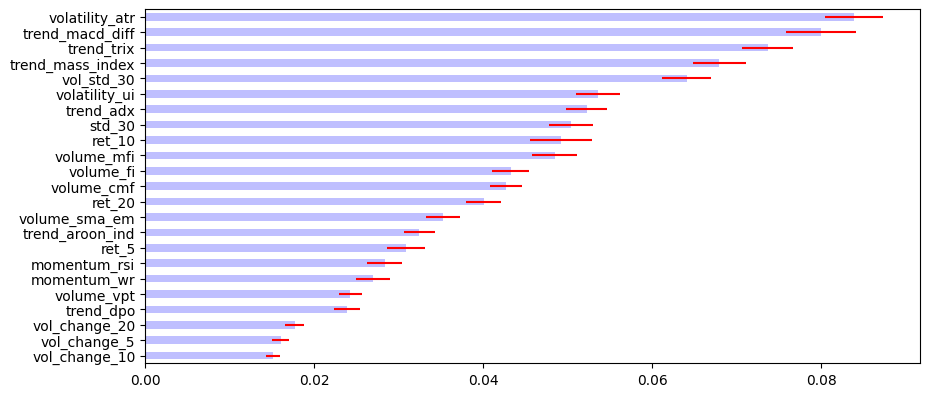

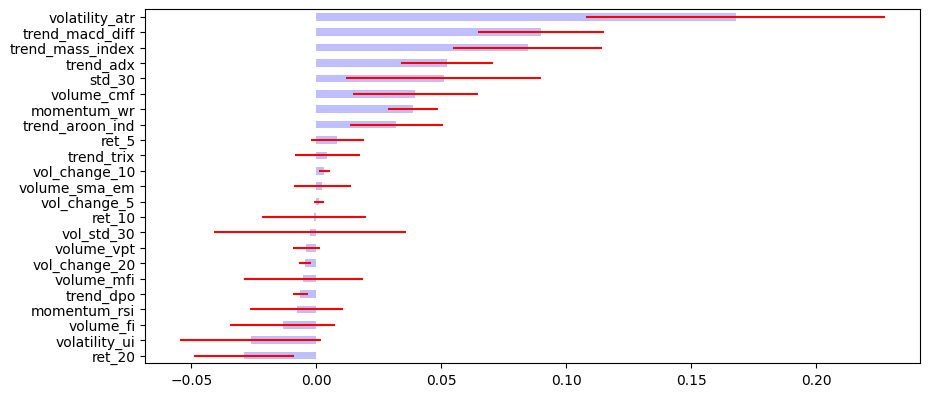

In [94]:
# Q. 코드를 작성해주세요

# feat_imp 확인
plot_feature_importance(feat_imp)
# feat_imp_mda 확인
plot_feature_importance(feat_imp_mda)


RFE CV, Recursive Feature Elimination

In [96]:
# Q. 코드를 작성해주세요

# RFE CV, Recursive Feature Elimination
svc_rbf = SVC(kernel='linear', probability=True)
rfe_cv = RFECV(svc_rbf, cv=cv) # RFECV
rfe_fitted = rfe_cv.fit(X_sc, y) # fit

In [97]:
# 선택된 피쳐 확인하기

rfe_df = pd.DataFrame([rfe_fitted.support_, rfe_fitted.ranking_], columns=X_sc.columns).T.rename(columns={0:"Optimal_Features", 1:"Ranking"})
rfe_df

,Optimal_Features,Ranking
volume_cmf,False,12
volume_fi,False,4
volume_mfi,False,14
volume_sma_em,False,7
volume_vpt,False,8
volatility_atr,True,1
volatility_ui,False,11
trend_macd_diff,True,1
trend_adx,False,19
trend_trix,False,10


In [98]:
rfe_df[rfe_df["Optimal_Features"]==True]

,Optimal_Features,Ranking
volatility_atr,True,1
trend_macd_diff,True,1
std_30,True,1


SFS, Sequential Feature Selection

In [99]:
# SFS, Sequential Feature Selection

n = 2

sfs_forward = SequentialFeatureSelector(svc_rbf, n_features_to_select=n, direction='forward')
sfs_fitted = sfs_forward.fit(X_sc, y)

In [100]:
# 선택된 피쳐 확인하기

sfs_rank = sfs_fitted.get_support()
sfs_df = pd.DataFrame(sfs_rank, index=X_sc.columns, columns=["Optimal_Features"])

sfs_df [sfs_df ["Optimal_Features"]==True].index

Index(['volume_mfi', 'trend_macd_diff'], dtype='object')

SHAP, Shapley Additive explanations

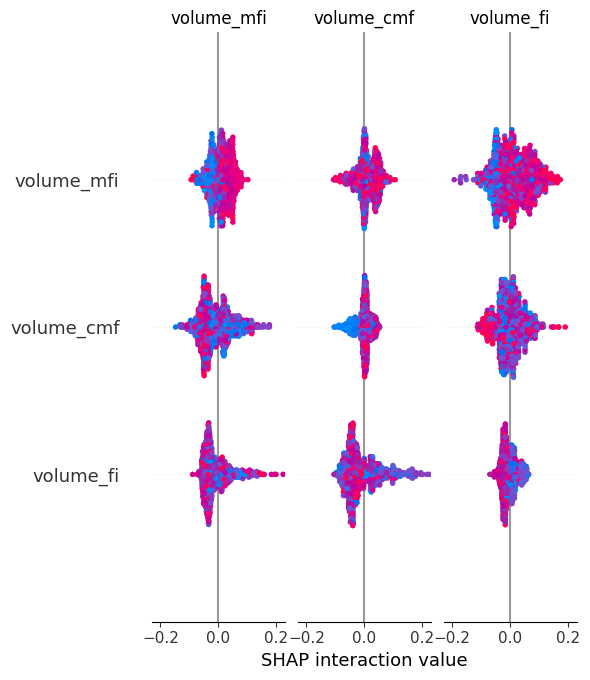

In [102]:
# Q. 코드를 작성해주세요

# SHAP, Shapley Additive explanations
import shap
explainer = shap.TreeExplainer(rfc, model_output="raw")
shap_value = explainer.shap_values(X_sc)

# shap_value, X_sc 사용 shap.summary_plot 그리기
shap.summary_plot(shap_value, X_sc)

In [103]:
output_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_feature_labels.pkl')
df_tmp_data.to_pickle(output_file_name)

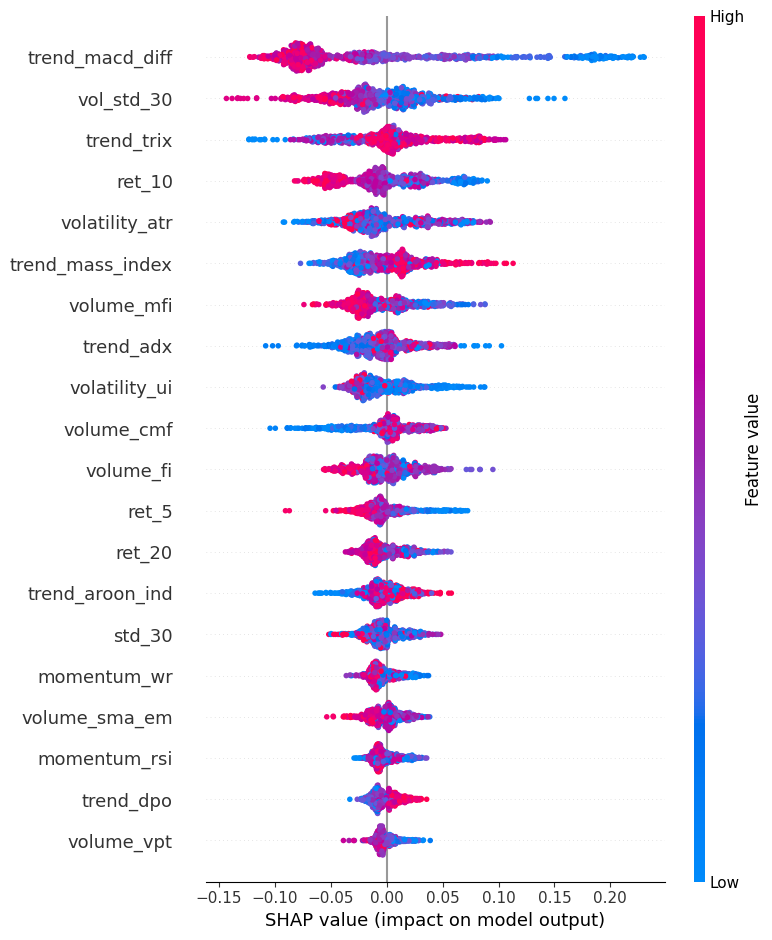

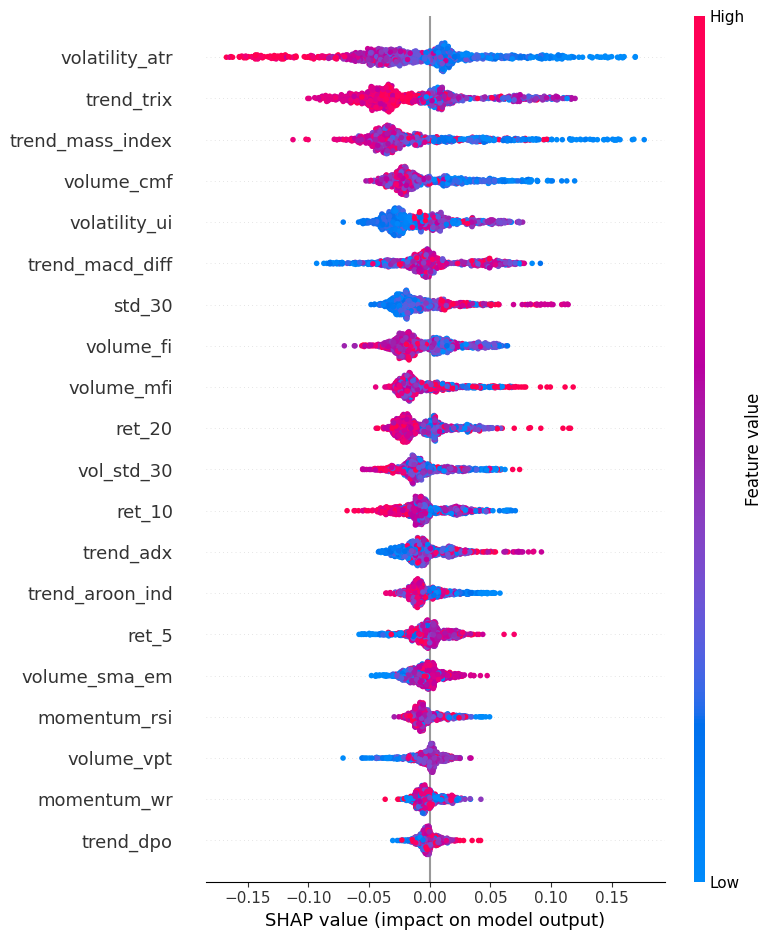

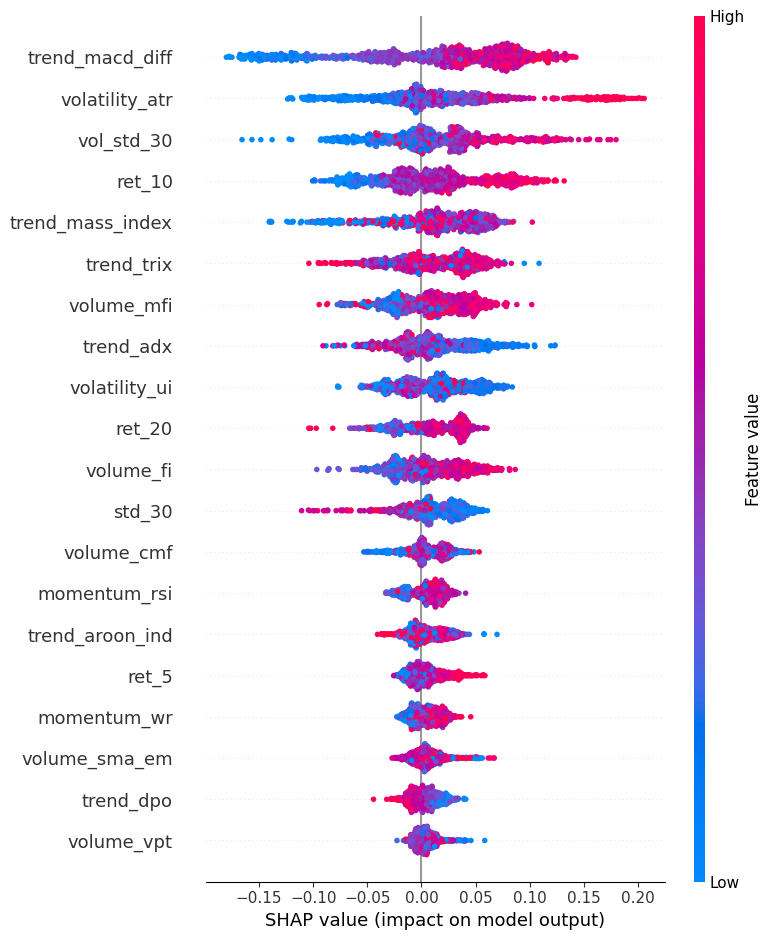

In [104]:
# 각 클래스에 대한 각각의 plot을 그려줌

# 클래스 0에 대한 SHAP summary plot
shap.summary_plot(shap_value[:, :, 0], X_sc, class_names='class 0')

# 클래스 1
shap.summary_plot(shap_value[:, :, 1], X_sc, class_names='class 1')

# 클래스 2
shap.summary_plot(shap_value[:, :, 2], X_sc, class_names='class 2')

In [105]:
# 절댓값 평균으로 전체 feature 중요도 요약
mean_shap = np.mean(np.abs(shap_value), axis=(0, 2))  # over samples and classes
shap_df = pd.Series(mean_shap, index=X_sc.columns).sort_values(ascending=False)
print(shap_df)

trend_macd_diff     0.053789
volatility_atr      0.040361
trend_trix          0.033150
trend_mass_index    0.032583
vol_std_30          0.029602
ret_10              0.028315
volatility_ui       0.023532
volume_mfi          0.023032
trend_adx           0.021219
volume_fi           0.020726
volume_cmf          0.019081
ret_20              0.018879
std_30              0.018079
trend_aroon_ind     0.012872
ret_5               0.012362
momentum_rsi        0.010741
volume_sma_em       0.010237
momentum_wr         0.009724
trend_dpo           0.008275
volume_vpt          0.007462
vol_change_20       0.004006
vol_change_10       0.003274
vol_change_5        0.003098
dtype: float64


In [106]:
output_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_feature_labels.pkl')
df_tmp_data.to_pickle(output_file_name)

3. 프로젝트 : Model Traning

① 환경구성 및 데이터 불러오기
② Purged K-fold for Cross-Validation적용하기
③ Model 적용하기

In [107]:
# ① 환경구성 및 데이터 불러오기

import datetime
import sys
import os
import re
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score, roc_curve


In [108]:
"""
Created on Fri Dec  6 19:41:30 2019

@author: sukji
"""
from typing import Callable
import pandas as pd
import numpy as np

from sklearn.metrics import log_loss
from sklearn.model_selection import KFold
from sklearn.base import ClassifierMixin
from sklearn.model_selection import BaseCrossValidator

def ml_get_train_times1(samples_info_sets: pd.Series, test_times: pd.Series) -> pd.Series:
    # pylint: disable=invalid-name
    """
    Advances in Financial Machine Learning, Snippet 7.1, page 106.

    Purging observations in the training set

    This function find the training set indexes given the information on which each record is based
    and the range for the test set.
    Given test_times, find the times of the training observations.

    :param samples_info_sets: (pd.Series) The information range on which each record is constructed from
        *samples_info_sets.index*: Time when the information extraction started.
        *samples_info_sets.value*: Time when the information extraction ended.
    :param test_times: (pd.Series) Times for the test dataset.
    :return: (pd.Series) Training set
    """
    train = samples_info_sets.copy(deep=True)

    start = test_times.min()
    end = test_times.max()

    first = test_times.index[0]
    last = test_times.index[-1]

    df0 = train[(train < first) | (train.index > end)].index  # Train starts within test
    return df0

class PKFold(KFold):
    """
    Extend KFold class to work with labels that span intervals

    The train is purged of observations overlapping test-label intervals
    Test set is assumed contiguous (shuffle=False), w/o training samples in between

    :param n_splits: (int) The number of splits. Default to 3
    :param samples_info_sets: (pd.Series) The information range on which each record is constructed from
        *samples_info_sets.index*: Time when the information extraction started.
        *samples_info_sets.value*: Time when the information extraction ended.
    :param pct_embargo: (float) Percent that determines the embargo size.
    """

    def __init__(self,
                 n_splits: int = 3,
                 samples_info_sets: pd.Series = None,
                 pct_embargo: float = 0.):

        if not isinstance(samples_info_sets, pd.Series):
            raise ValueError('The samples_info_sets param must be a pd.Series')
        super(PKFold, self).__init__(n_splits, shuffle=False, random_state=None)

        self.samples_info_sets = samples_info_sets
        self.pct_embargo = pct_embargo

    # noinspection PyPep8Naming
    def split(self,
              X: pd.DataFrame,
              y: pd.Series = None,
              groups=None):
        """
        The main method to call for the PurgedKFold class

        :param X: (pd.DataFrame) Samples dataset that is to be split
        :param y: (pd.Series) Sample labels series
        :param groups: (array-like), with shape (n_samples,), optional
            Group labels for the samples used while splitting the dataset into
            train/test set.
        :return: (tuple) [train list of sample indices, and test list of sample indices]
        """
        if X.shape[0] != self.samples_info_sets.shape[0]:
            raise ValueError("X and the 'samples_info_sets' series param must be the same length")

        indices: np.ndarray = np.arange(X.shape[0])
        embargo: int = int(X.shape[0] * self.pct_embargo)

        test_ranges: [(int, int)] = [(ix[0], ix[-1] + 1) for ix in np.array_split(np.arange(X.shape[0]), self.n_splits)]
        for start_ix, end_ix in test_ranges:
            test_indices = indices[start_ix:end_ix]

            if end_ix < X.shape[0]:
                end_ix += embargo

            test_times = pd.Series(index=[self.samples_info_sets.index[start_ix]], data=[self.samples_info_sets[end_ix-1]])
            #train_times = ml_get_train_times(self.samples_info_sets, test_times)
            train_times = ml_get_train_times1(self.samples_info_sets, test_times)

            train_indices = []
            for train_ix in train_times:
                train_indices.append(self.samples_info_sets.index.get_loc(train_ix))
            yield np.array(train_indices), test_indices

In [109]:
# 데이터 경로 설정 및 pickle 파일 불러오기
DATA_PATH = '/content/drive/MyDrive/SQL_modu/1124_finance/'
data_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_feature_labels.pkl')

# 여기서부터 모델에 적용하기 위한 데이터 정제화를 시작합니다.
df_data = pd.read_pickle(data_file_name)
df_data['t_value'] = df_data['t_value'].apply(lambda x: x if x == 1 else 0)

df_data['t_value'].value_counts()

# 데이터셋 비율 나누기
train_ratio, test_ratio = 0.7, 0.2
n_train = int(np.round(len(df_data) * train_ratio))
n_test = int(np.round(len(df_data) * test_ratio))

X, y = df_data.iloc[:, 5:-1], df_data.iloc[:, -1]

# standardzation
sc = StandardScaler()
X_sc = sc.fit_transform(X)

# 데이터셋 분리
train_x, test_x, train_y, test_y = X_sc[:n_train, :], X_sc[-n_test:, :], y.iloc[:n_train], y.iloc[-n_test:]

train_x = pd.DataFrame(train_x, index=train_y.index, columns=X.columns)
train_y = pd.Series(train_y, index=train_y.index)
test_x = pd.DataFrame(test_x, index=test_y.index, columns=X.columns)
test_y = pd.Series(test_y, index=test_y.index)

# 학습 시간 단축을 위해 여기선 편의상 1000개의 데이터만 가져옵니다.
train_x = train_x[:1000] # 데이터셋을 증가 혹은 감소시켜 결과를 비교해봅시다.
train_y = train_y[:1000]

In [110]:
train_x

,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,volatility_atr,volatility_ui,trend_macd_diff,trend_adx,trend_trix,...,momentum_rsi,momentum_wr,vol_change_5,ret_5,vol_change_10,ret_10,vol_change_20,ret_20,std_30,vol_std_30
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:43:00,1.035464,-0.186753,0.065427,0.391695,0.143181,1.474065,0.054076,0.103695,0.930692,-0.078062,...,-0.141586,0.073599,-0.268825,-0.053926,-0.273922,-0.077989,-0.359687,0.617241,-0.335632,0.273404
2018-01-01 00:44:00,1.054026,0.125880,-0.011156,0.814123,0.544363,1.478520,0.017250,0.639945,0.771813,-0.051294,...,0.344922,1.111779,-0.209690,2.237163,-0.263511,0.036043,-0.266915,0.940844,-0.262646,0.291664
2018-01-01 00:45:00,1.042978,-0.023653,0.063195,1.052689,0.218332,1.290057,-0.020738,0.714133,0.598850,-0.015958,...,0.067032,0.544625,-0.124252,0.554780,-0.278339,0.150308,-0.252720,0.942325,-0.237456,0.301886
2018-01-01 00:46:00,1.016133,0.880060,-0.281931,0.928143,1.068429,1.633699,-0.020738,1.434675,0.454452,0.071047,...,0.783648,1.457839,0.168697,2.536405,-0.228841,0.833801,-0.227291,1.672326,-0.022928,0.256716
2018-01-01 00:47:00,0.893440,0.486864,-0.562722,-0.026395,0.862103,1.942977,0.088583,0.921217,0.319680,0.131133,...,-0.191611,-0.257415,-0.080204,0.402681,-0.380178,0.036276,-0.340320,0.454122,-0.018291,0.317671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 11:48:00,-0.401194,-0.656959,0.475561,-1.100167,-0.521844,1.844790,-0.113705,-0.282812,-0.360223,0.287789,...,-0.516289,-0.791551,0.022479,-1.231068,-0.267438,-0.410544,-0.263846,-0.738733,0.586925,0.396518
2018-01-01 11:49:00,-0.183171,-0.400958,0.585458,-1.100167,-0.085709,1.683858,-0.156036,-0.278606,-0.324160,0.297117,...,-0.032056,-0.099431,-0.228529,-0.642497,-0.196571,0.143791,-0.319728,0.911545,0.471733,0.351625
2018-01-01 11:50:00,-0.373766,-0.476587,0.944141,-1.018990,0.064538,1.346547,-0.186992,-0.345393,-0.290502,0.295249,...,-0.155044,-0.272461,-0.248446,-0.201379,-0.192556,-0.961155,-0.121272,1.230046,0.256260,0.119151


Purged K-fold for Cross-Validation

In [114]:
# ② Purged K-fold for Cross-Validation적용
"""
금융시계열은 샘플 간 상관(시간 의존성) 이 강해서, 폴드를 너무 잘게 쪼개면
각 폴드에 들어가는 기간이 너무 짧아져서 일관된 패턴을 학습·검증하기 어려움.
데이터 양·기간을 고려해서 “적당히” 나누는 값으로 4를 사용하여 각 폴드에 25% 정도씩 시간 구간이
들어가고,→ PurgedKFold + embargo까지 넣어도 훈련/검증에 쓸 데이터가 충분히 남는 수준이라 안정적
"""

n_cv = 3
# 앞에서 지정한 값은 4입니다. 얼마를 넣을지 생각해보고 왜 이 값을 넣었는지에 대해서 설명해봅시다.
t1 = pd.Series(train_y.index.values, index=train_y.index)
# purged K-Fold
cv = PKFold(n_cv, t1, 0)

In [116]:
# ③ Model 적용하기

# GridsearchCV에서 사용할 파라미터 설정합니다. 파라미터값을 바꿔보세요
"""
n_estimators: 3
max_features: 2
max_depth: 4
max_features(내부 RF): 2
min_samples_leaf: 3
bootstrap_features: 2
: 3 × 2 × 4 × 2 × 3 × 2 = 288 조합
"""

bc_params = {'n_estimators': [5, 10],
             'max_features': [0.5],
             'estimator__max_depth': [5,10],
             'estimator__max_features': [None],
             'estimator__min_samples_leaf': [3, 5],
             'bootstrap_features': [False]
            }

In [117]:
# RandomForest 사용
rfc = RandomForestClassifier(class_weight='balanced')

In [118]:
# Q. 코드를 작성해주세요

# Bagging 적용
bag_rfc = BaggingClassifier(rfc)

In [119]:
# Q. 코드를 작성해주세요

# GridSearchCV 적용
gs_rfc = GridSearchCV(bag_rfc, bc_params, cv=cv, n_jobs=-1, verbose=1)

In [121]:
# fit
gs_rfc.fit(train_x, train_y)

# best estimator
gs_rfc_best = gs_rfc.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [122]:
gs_rfc_best.fit(train_x, train_y)

BaggingClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                   max_depth=5,
                                                   max_features=None,
                                                   min_samples_leaf=3),
                  max_features=0.5, n_estimators=5)

In [123]:
# 예측값 확인
pred_y = gs_rfc_best.predict(test_x)
prob_y = gs_rfc_best.predict_proba(test_x)

In [124]:
# Q. 코드를 작성해주세요

# test_y, pred_y를 활용한 지표 적용
confusion = confusion_matrix(test_y, pred_y)
accuracy  = accuracy_score(test_y, pred_y)
precision = precision_score(test_y, pred_y)
recall    = recall_score(test_y, pred_y)

# 지표를 통한 결과 확인
print('================= confusion matrix ====================')
print(confusion)
print('=======================================================')
print(f'정확도:{accuracy}, 정밀도:{precision}, 재현율:{recall}')

================= confusion matrix ====================
[[82 54]
 [12 43]]
정확도:0.6544502617801047, 정밀도:0.44329896907216493, 재현율:0.7818181818181819


auc:0.8171122994652407


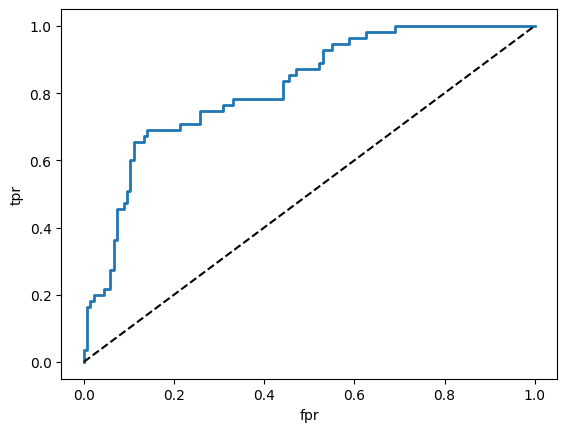

In [125]:
# Q. 코드를 작성해주세요

# ROC curve 만들기
fpr, tpr, thresholds = roc_curve(test_y, prob_y[:,1])
auc = roc_auc_score(test_y, prob_y[:,1])

# ROC curve 시각화
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
plt.xlabel('fpr')
plt.ylabel('tpr')
print(f'auc:{auc}')

0. PJT 요약 _______________________________________________

- 금융 시계열 데이터를 기반으로,
데이터 라벨링 → 특징공학 → 모델링 → 성능평가 실시


- Data Labeling (4개 방식)
- Feature Engineering (Technical Index + Feature Selection)
- Model Training (Purged K-Fold + Bagging + RF + GridSearchCV)

1. Data Labeling _______________________________________________

시계열 종가 데이터를 이용해 4가지 방식으로 라벨 생성

- (1) Price Change Direction - n기간 전 대비 현재 종가 상승 여부로 label 생성 (상승 red, 하락 green)
- (2) Using Moving Average - 현재 종가 vs 이동평균(MA) 비교
- (3) Local Min–Max - 지역 최소/최대값 기반으로 추세 반전 시점 포착
    - get_local_min_max 함수 작성
    - mins, maxes 각각을 scatter plot으로 시각화
    - → 추세 전환을 명확하게 포착 가능.
- (4) Trend Scanning (OLS 기반 t-value) - 일정 구간을 OLS로 회귀
    - slope의 t-value로 추세 판단
    - t-value 최대치의 부호(sign)로 라벨 결정
    - 계산 비용 크지만, 가장 구조적인 추세 기반 라벨링

2. Feature Engineering _______________________________________________
- Technical Indicators (TA library, 4개 카테고리 20+ 개 특징 생성)
    - Volume Indicators : CMF, MFI, FI, VPT, SMA EM 등
    - Volatility Indicators : ATR, Ulcer Index
    - Trend Indicators : MACD diff, ADX, TRIX, DPO, AROON, Mass Index 등
    - Momentum Indicators : RSI, Williams %R 등
- 수익률 및 변동성 특징 추가
    - pct_change 기반 mom / volume 변화율
    - rolling std 기반 close / volume 변동성
      → 최종 feature 약 28개
- Standard Scaling
    - 모든 feature 표준화하여 RandomForest에 입력.
3. Model Training _______________________________________________
- Train/Test Split
    - train 70%, test 20%
    - 10% validation or cross-validation
- Purged K-Fold 적용
    - 금융 시계열 누수 방지를 위해 PKFold 사용 (n_cv = 3)
      → fold 간 시간 겹침 제거 + embargo 적용
- 모델 선택 : RandomForestClassifier + Bagging
- GridSearchCV (사용한 파라미터:)
            n_estimators: [5, 10]
            max_features: [0.5]
            estimator__max_depth: [5,10]
            estimator__max_features: [None]
            estimator__min_samples_leaf: [3,5]
            bootstrap_features: [False]

4. 최종 모델 성능 _______________________________________________
- Accuracy: 0.6544502617801047
        전체 예측 중 65%를 맞춤
        (전체 성능의 분위기 정도만 알려주는 보조 지표)
- Precision: 0.44329896907216493
        모델이 “상승이다”라고 예측한 것 중 실제로 오른 경우는 44%
        (모델이 매수해도 된다고 하는 신호 중 절반은 거짓)
- Recall: 0.7818181818181819
        전체 상승 구간 중 78%를 잘 잡아냄.
        (상승 구간을 10개 중 8개 정도는 잘 찾아낸다)

5. 전체 프로젝트 핵심 요약
- 4가지 라벨링 기법 → 데이터 성격에 따라 다른 라벨 생성
- TA 기반 feature engineering 및 변동성/모멘텀 특징 생성
- SHAP, MDI, MDA, RFE, SFS 등 여러 Feature Selection 기법 실험
- Purged K-Fold 적용해 금융 시계열 누수 방지
- RF + Bagging + GridSearch로 모델 튜닝
- 랜덤성으로 인해 결과가 재현되지 않을 수 있음 → seed 적용으로 해결하면됨.


⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗⩗



👉 개선 시도 1 : 고상관 피쳐 제거
       
        - 서로 중복된 feature + 노이즈 feature가 Precision을 떨어뜨리므로,
        - 상관계수 기반 0.9 이상을제거해서 과적합을 줄여서 Precision을 높여보자.

In [129]:
X_sc = sc.fit_transform(X)

# DataFrame 변환
X_sc = pd.DataFrame(X_sc, index=X.index, columns=X.columns)

In [130]:
import numpy as np

# 1) 상관계수 행렬 (절대값)
corr_matrix = X_sc.corr().abs()

# 2) Upper triangle만 추출 (대칭이니까 절반만 보면 됨)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3) threshold 이상인 경우 제거 대상 컬럼 수집
threshold = 0.9   # 0.8~0.95 선호, 여기 값 바꿔가며 실험해봐도 좋아요
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print("제거할 고상관 feature들:")
print(to_drop)

# 4) 실제로 feature 제거
X_sc_reduced = X_sc.drop(columns=to_drop)


제거할 고상관 feature들:
[]


개선시도 1 결과, 고상관 (0.9이상) 피쳐 없음

생각 - 재현율은 높으나 정밀도 낮으므로 정밀도를 높여보자.


구현 - 정밀도를 높이는 방법 : (1) threshold 를 높여서 모델의 확신이 더 높을 때 상승으로 예측하도록 유도

👉 개선 시도 2 : threshold 높이기
       
        - 금융 데이터는 클래스 불균형, 노이즈가 심해서 “0.5”가 최적 기준이 아닐 수 있음.
        - threshold = 0.6 또는 0.7로 올려, 정밀도 up,재현율은 허용범위내에서 down하여 진행

In [131]:
# 현재 결과에서 threshold 만 변경 진행
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

prob_pos = gs_rfc_best.predict_proba(test_x)[:, 1]

thresholds = np.arange(0.3, 0.81, 0.05)  # 0.30 ~ 0.80 까지 0.05 간격
results = []

for th in thresholds:
    pred_th = (prob_pos >= th).astype(int)

    acc  = accuracy_score(test_y, pred_th)
    prec = precision_score(test_y, pred_th, zero_division=0)
    rec  = recall_score(test_y, pred_th, zero_division=0)
    f1   = f1_score(test_y, pred_th, zero_division=0)

    results.append([th, acc, prec, rec, f1])

# 결과를 보기 좋게 출력
print("th\tAcc\tPrec\tRec\tF1")
for th, acc, prec, rec, f1 in results:
    print(f"{th:.2f}\t{acc:.3f}\t{prec:.3f}\t{rec:.3f}\t{f1:.3f}")


th	Acc	Prec	Rec	F1
0.30	0.571	0.398	0.964	0.564
0.35	0.592	0.405	0.891	0.557
0.40	0.602	0.410	0.873	0.558
0.45	0.634	0.430	0.836	0.568
0.50	0.654	0.443	0.782	0.566
0.55	0.712	0.500	0.745	0.599
0.60	0.738	0.533	0.727	0.615
0.65	0.759	0.565	0.709	0.629
0.70	0.791	0.623	0.691	0.655
0.75	0.822	0.706	0.655	0.679
0.80	0.796	0.682	0.545	0.606


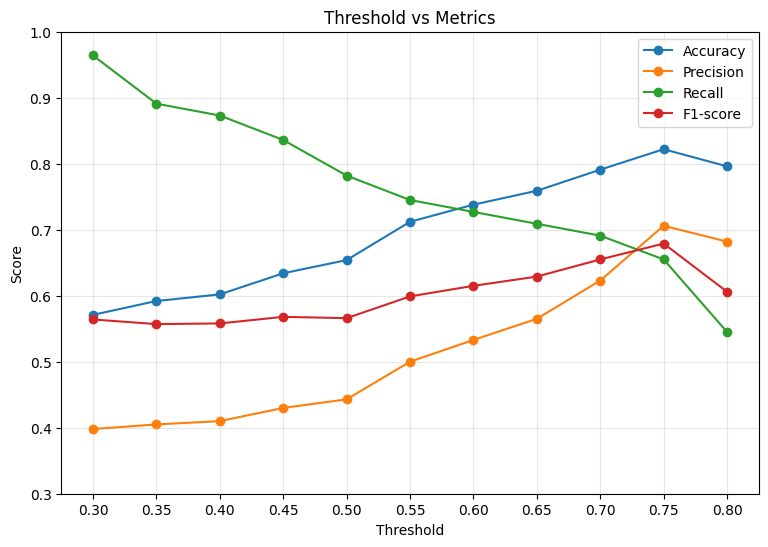

In [134]:
# 시각화

import pandas as pd
import matplotlib.pyplot as plt

# 1) 데이터프레임으로 정리
data = {
    "th":   [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80],
    "Acc":  [0.571, 0.592, 0.602, 0.634, 0.654, 0.712, 0.738, 0.759, 0.791, 0.822, 0.796],
    "Prec": [0.398, 0.405, 0.410, 0.430, 0.443, 0.500, 0.533, 0.565, 0.623, 0.706, 0.682],
    "Rec":  [0.964, 0.891, 0.873, 0.836, 0.782, 0.745, 0.727, 0.709, 0.691, 0.655, 0.545],
    "F1":   [0.564, 0.557, 0.558, 0.568, 0.566, 0.599, 0.615, 0.629, 0.655, 0.679, 0.606],
}
df_th = pd.DataFrame(data)

# 2) 시각화
plt.figure(figsize=(9,6))

plt.plot(df["th"], df["Acc"],  marker="o", label="Accuracy")
plt.plot(df["th"], df["Prec"], marker="o", label="Precision")
plt.plot(df["th"], df["Rec"],  marker="o", label="Recall")
plt.plot(df["th"], df["F1"],   marker="o", label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Metrics")
plt.xticks(df["th"])        # x축에 임계값 그대로 찍기
plt.ylim(0.3, 1.0)          # 범위 설정
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [136]:
#F1-score 기준 최적 threshold 찾기
best_idx = df_th["F1"].idxmax()
best_row = df_th.loc[best_idx]

best_th   = best_row["th"]
best_acc  = best_row["Acc"]
best_prec = best_row["Prec"]
best_rec  = best_row["Rec"]
best_f1   = best_row["F1"]

print("=== F1-score 기준 최적 Threshold 탐색 결과 ===")
print(f"- 최적 임곗값 (th): {best_th:.2f}")
print(f"- Accuracy       : {best_acc:.3f}")
print(f"- Precision      : {best_prec:.3f}")
print(f"- Recall         : {best_rec:.3f}")
print(f"- F1-score       : {best_f1:.3f}")

# ④ baseline(예: th=0.50)과 비교해서 결론 요약
baseline_row = df_th[df_th["th"] == 0.50].iloc[0]

print("\n=== 기준(th=0.50) vs 최적(th={:.2f}) 비교 ===".format(best_th))
print(f"[기준 th=0.50] Acc={baseline_row['Acc']:.3f}, Prec={baseline_row['Prec']:.3f}, "
      f"Rec={baseline_row['Rec']:.3f}, F1={baseline_row['F1']:.3f}")
print(f"[최적 th={best_th:.2f}] Acc={best_acc:.3f}, Prec={best_prec:.3f}, "
      f"Rec={best_rec:.3f}, F1={best_f1:.3f}")

# ⑤ 간단한 자연어 결론까지 출력
print("\n[결론]")
print(f"- 이 실험에서는 F1-score 기준으로 볼 때 threshold={best_th:.2f}가 가장 좋습니다.")
print("- 기본 0.50 대비:")
print(f"  · Accuracy  : {baseline_row['Acc']:.3f} → {best_acc:.3f}")
print(f"  · Precision : {baseline_row['Prec']:.3f} → {best_prec:.3f}")
print(f"  · Recall    : {baseline_row['Rec']:.3f} → {best_rec:.3f}")
print("- 즉, 임곗값을 {0:.2f}로 올리면 '양성이라고 예측한 것 중 실제 양성 비율(Precision)'이 크게 개선되고,".format(best_th))
print("  약간의 Recall 감소를 감수하는 대신, 전체 예측 품질(F1, Accuracy)이 가장 좋아집니다.")


=== F1-score 기준 최적 Threshold 탐색 결과 ===
- 최적 임곗값 (th): 0.75
- Accuracy       : 0.822
- Precision      : 0.706
- Recall         : 0.655
- F1-score       : 0.679

=== 기준(th=0.50) vs 최적(th=0.75) 비교 ===
[기준 th=0.50] Acc=0.654, Prec=0.443, Rec=0.782, F1=0.566
[최적 th=0.75] Acc=0.822, Prec=0.706, Rec=0.655, F1=0.679

[결론]
- 이 실험에서는 F1-score 기준으로 볼 때 threshold=0.75가 가장 좋습니다.
- 기본 0.50 대비:
  · Accuracy  : 0.654 → 0.822
  · Precision : 0.443 → 0.706
  · Recall    : 0.782 → 0.655
- 즉, 임곗값을 0.75로 올리면 '양성이라고 예측한 것 중 실제 양성 비율(Precision)'이 크게 개선되고,
  약간의 Recall 감소를 감수하는 대신, 전체 예측 품질(F1, Accuracy)이 가장 좋아집니다.


: 결론,

- F1  최고: th = 0.75 (F1=0.679,Precision: 0.44, Recall:0.655)
- 기본 0.50일 때:  Accuracy: 0.654, Prec=0.443, Rec=0.782, F1=0.566
- 임계값 0.75 변경 시, Accuracy: 0.65 → 0.82 (0.17↑) / Precision: 0.44 → 0.71 (0.29 ↑) / Recall: 0.78 → 0.66 (0.12↓)

==>   거짓 양성(False Positive)을 줄이고, 모델의 상승 확신 경우만 선택하고자 할 경우, th ≈ 0.75를 쓰는 게 합리적 일 것이다.